In [ ]:

from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import string
import re
from itertools import combinations
import torch
from torch_geometric.data import HeteroData
from torch_geometric.nn import RGCNConv, HeteroConv, GCNConv, SAGEConv
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import networkx as nx
from sklearn.metrics import accuracy_score, f1_score
from sklearn.manifold import TSNE

/lv_local/home/omer.y/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_data(dset_path, has_labels=True):
    with open(dset_path) as f:
        lines = f.read().splitlines()
        # remove punctuation from the text
    removePunc = list()
    # remove extra spaces and the punctuation and the symbol "-"
    [removePunc.append(line.replace(" -", "").translate(str.maketrans('', '', string.punctuation)).replace("  ", " "))
    for line in lines]

    # split the lines according to "\t" since the different instances in a line of one example are separated by "\t"
    splitList = [line.split('\t') for line in removePunc]
    # turning to numpy array for in order to use numpy functionality
    npArray = np.array(splitList)
    # getting the left side examples
    leftCol = npArray[:, 0].tolist()
    # getting the right side examples
    rightCol = npArray[:, 1].tolist()
    # if the dataset is with labels (train, valid) then extract also the labels from the file
    if has_labels:
        # getting the labels of the pairs
        label = npArray[:, 2].tolist()
        return leftCol, rightCol, label
    else:
        return leftCol, rightCol

In [ ]:
dset_path = "data/er_magellan/Structured/iTunes-Amazon/train.txt"
noisy_dset_path = "Noisy/er_magellan/Structured/iTunes-Amazon/iTunes-AmazonBert/train.txt"
val_dset_path = "data/er_magellan/Structured/iTunes-Amazon/valid.txt"
test_dset_path = "data/er_magellan/Structured/iTunes-Amazon/test.txt"
# get the data
train_left, train_right, labels = get_data(dset_path)
val_left, val_right, val_labels = get_data(val_dset_path)
test_left, test_right, test_labels = get_data(test_dset_path)
left = train_left + val_left + test_left
right = train_right + val_right + test_right
_, _, noisy_labels = get_data(noisy_dset_path)
labels = [int(l) for l in labels] + [int(l) for l in val_labels] + [int(l) for l in test_labels]
noisy_labels = [int(l) for l in noisy_labels] + [int(l) for l in val_labels] + [int(l) for l in test_labels]
# create masks:
train_mask = [1]*len(train_left) + [0]*len(val_left) + [0]*len(test_left)
val_mask = [0]*len(train_left) + [1]*len(val_left) + [0]*len(test_left)
test_mask = [0]*len(train_left) + [0]*len(val_left) + [1]*len(test_left)


## Build Hetero Graph

In [4]:
def parse_attr(line):
    parsed_line = {}
    splitline = line.split('COL ')[1:]
    for tokens in splitline:
        val_split = tokens.split('VAL ')
        key = val_split[0].strip()
        val = val_split[1].strip()
        parsed_line[key] = val
    return parsed_line

def embed_dict(parsed_line, model):
    embedded_dict = {}
    with torch.no_grad():
        for key, val in parsed_line.items():
            embedded_dict[key] = model.encode(val)
    return embedded_dict

def extract_mutual_agreement(left_dict, right_dict):
    mutual_agreement = {}
    for key in left_dict.keys():
        if key in right_dict.keys():
            left_emb = left_dict[key]
            right_emb = right_dict[key]
            sim = np.dot(left_emb, right_emb)/(np.linalg.norm(left_emb)*np.linalg.norm(right_emb))
            mutual_agreement[key] = sim
    return mutual_agreement

In [5]:
print(clean_left[0])
print(parse_attr(clean_left[0]))
print()
print(clean_right[0])
print(parse_attr(clean_right[0]))

COL SongName VAL Illusion feat Echosmith COL ArtistName VAL Zedd COL AlbumName VAL True Colors COL Genre VAL Dance Music Electronic COL Price VAL 129 COL CopyRight VAL 2015 Interscope Records COL Time VAL 630 COL Released VAL 18May15 
{'SongName': 'Illusion feat Echosmith', 'ArtistName': 'Zedd', 'AlbumName': 'True Colors', 'Genre': 'Dance Music Electronic', 'Price': '129', 'CopyRight': '2015 Interscope Records', 'Time': '630', 'Released': '18May15'}

COL SongName VAL Transmission feat X Ambassadors COL ArtistName VAL Zedd COL AlbumName VAL True Colors COL Genre VAL Dance Electronic COL Price VAL 129 COL CopyRight VAL C 2015 Interscope Records COL Time VAL 402 COL Released VAL May 18 2015 
{'SongName': 'Transmission feat X Ambassadors', 'ArtistName': 'Zedd', 'AlbumName': 'True Colors', 'Genre': 'Dance Electronic', 'Price': '129', 'CopyRight': 'C 2015 Interscope Records', 'Time': '402', 'Released': 'May 18 2015'}


In [6]:
model = SentenceTransformer('all-MiniLM-L6-v2')
if torch.cuda.is_available():
    print("Using GPU")
    device = torch.device('cuda')
else:
    print("Using CPU")
    device = torch.device('cpu')
model = model.to(device)


Using GPU


In [ ]:
left_dict = embed_dict(parse_attr(left[0]), model)
right_dict = embed_dict(parse_attr(right[0]), model)


In [8]:
mutual_agreement = extract_mutual_agreement(left_dict, right_dict)
print("Mutual agreement:")
for key, val in mutual_agreement.items():
    print(f"{key}: {val:.4f}")

Mutual agreement:
SongName: 0.3039
ArtistName: 1.0000
AlbumName: 1.0000
Genre: 0.9347
Price: 1.0000
CopyRight: 0.9624
Time: 0.5306
Released: 0.6812


Linear transformation of cosine-similarity support $[-1, 1]$ to valid probability space $[0, 1]$ is:
\begin{align*}
    T(x) = \frac{1}{2} \cdot x + \frac{1}{2}
\end{align*}

In [9]:
def extract_agreement_pairs(left, right, model):
    attr_agreement = {}
    for i, (l, r) in tqdm(enumerate(zip(left, right))):
        l_dict = embed_dict(parse_attr(l), model)
        r_dict = embed_dict(parse_attr(r), model)
        mutual_agreement = extract_mutual_agreement(l_dict, r_dict)
        attr_agreement[i] = mutual_agreement
    return attr_agreement

def build_mutual_agreement_graph(attr_agreement, threshold=0.75, sample_edge=False, sampling_prob=0.5):
    data = HeteroData()
    nodes = set(attr_agreement.keys())
    # Add nodes to the graph
    data['node'].num_nodes = len(nodes)
    edges = {attr: [] for attr in next(iter(attr_agreement.values())).keys()}
    for node1, node2 in combinations(attr_agreement.keys(), 2):
        for attr in attr_agreement[node1].keys():
            # Check if both nodes have high agreement for this attribute
            if not sample_edge:
                if attr_agreement[node1][attr] >= threshold and attr_agreement[node2][attr] >= threshold:
                    edges[attr].append((node1, node2))
            else: # Sample edges based on agreement
                if attr_agreement[node1][attr] >= threshold and attr_agreement[node2][attr] >= threshold:
                    if np.random.rand() < sampling_prob:
                        edges[attr].append((node1, node2))
    
    # Convert to PyTorch tensors and store in HeteroData
    for attr, edge_list in edges.items():
        if edge_list:  # Ensure there are edges of this type
            edge_index = torch.tensor(edge_list, dtype=torch.long).T  # Convert to (2, num_edges)
            data["node", attr, "node"].edge_index = edge_index
    
    return data

In [ ]:
data_attr_agreement = extract_agreement_pairs(left, right, model)


321it [00:21, 14.77it/s]


In [49]:
mutual_agreement_graph = build_mutual_agreement_graph(data_attr_agreement, threshold=0.95, sample_edge=True, sampling_prob=0.5)

Number of nodes: 321
Number of edges per type:
('node', 'SongName', 'node'): 678
('node', 'ArtistName', 'node'): 18254
('node', 'AlbumName', 'node'): 1289
('node', 'Price', 'node'): 13281
('node', 'CopyRight', 'node'): 2048
('node', 'Time', 'node'): 825
Average degree per type:
('node', 'SongName', 'node'): 2.1121
('node', 'ArtistName', 'node'): 56.8660
('node', 'AlbumName', 'node'): 4.0156
('node', 'Price', 'node'): 41.3738
('node', 'CopyRight', 'node'): 6.3801
('node', 'Time', 'node'): 2.5701
Standard deviation of degree per type:
('node', 'SongName', 'node'): 69.2842
('node', 'ArtistName', 'node'): 74.8250
('node', 'AlbumName', 'node'): 67.4936
('node', 'Price', 'node'): 76.2008
('node', 'CopyRight', 'node'): 76.1242
('node', 'Time', 'node'): 65.1100


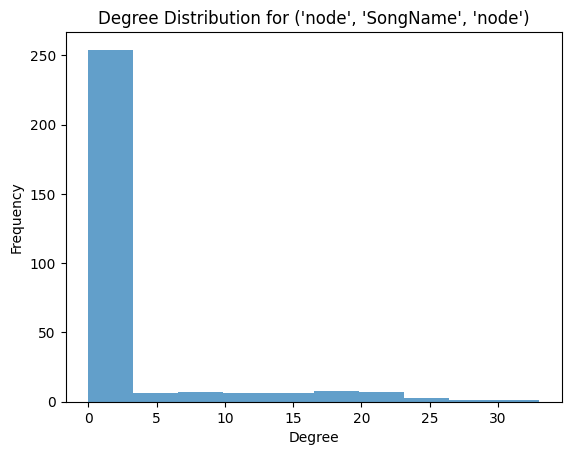

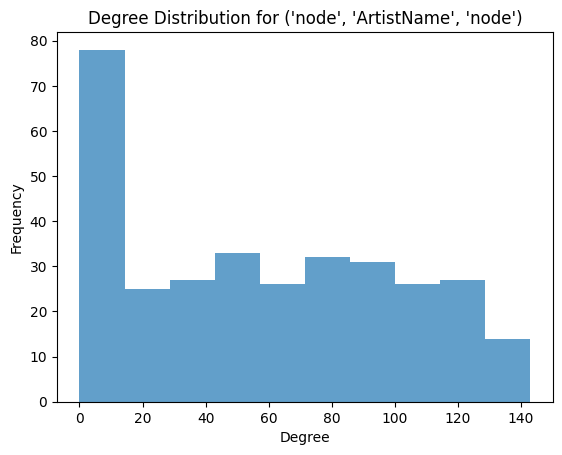

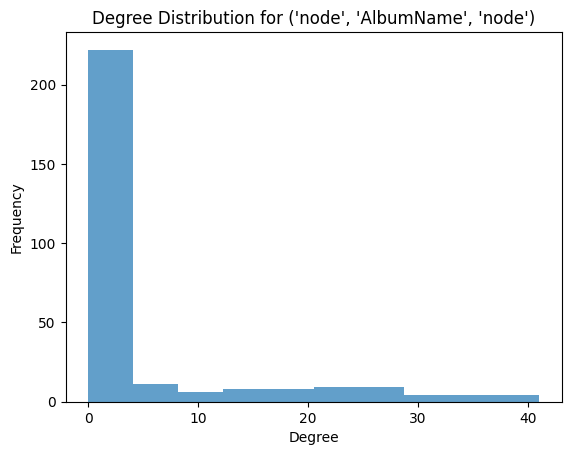

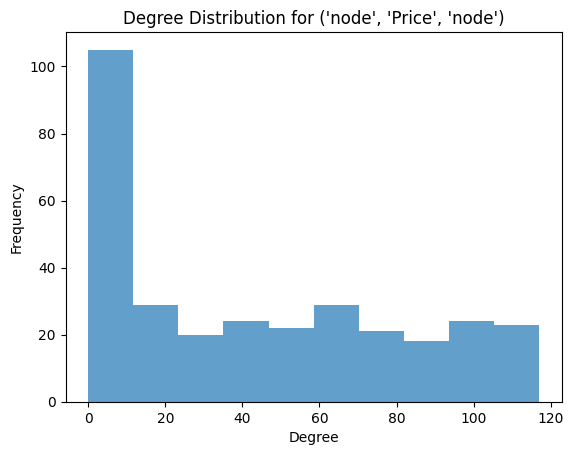

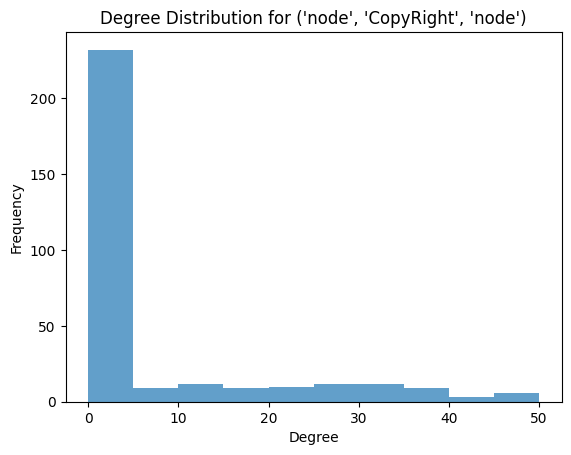

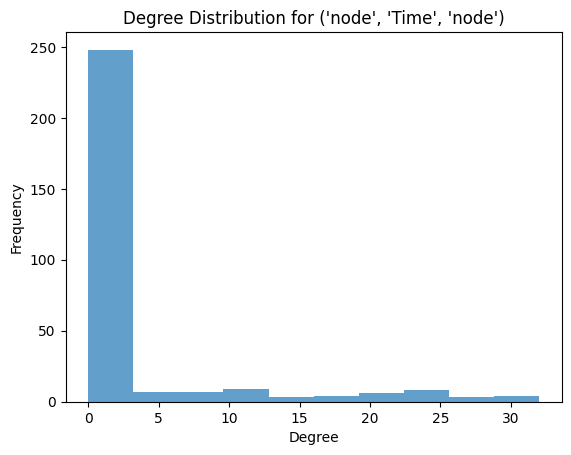

In [ ]:
# Statistics about the MAG:
num_edge_per_type = {}
num_nodes = len(left)
print(f"Number of nodes: {num_nodes}")
for edge_type in mutual_agreement_graph.edge_types:
    num_edge_per_type[edge_type] = mutual_agreement_graph[edge_type].edge_index.size(1)
print("Number of edges per type:")
for edge_type, num_edges in num_edge_per_type.items():
    print(f"{edge_type}: {num_edges}")
avg_degree_per_type = {}
std_degree_per_type = {}
for edge_type, num_edges in num_edge_per_type.items():
    avg_degree_per_type[edge_type] = num_edges / num_nodes
    std_degree_per_type[edge_type] = np.std(mutual_agreement_graph[edge_type].edge_index[0].numpy())
print("Average degree per type:")
for edge_type, avg_degree in avg_degree_per_type.items():
    print(f"{edge_type}: {avg_degree:.4f}")
print("Standard deviation of degree per type:")
for edge_type, std_degree in std_degree_per_type.items():
    print(f"{edge_type}: {std_degree:.4f}")
# Plotting the degree distribution
def plot_degree_distribution(data, edge_type):
    edge_index = data[edge_type].edge_index
    degrees = torch.bincount(edge_index[0])
    plt.hist(degrees.numpy(), bins=10, alpha=0.7)
    plt.title(f"Degree Distribution for {edge_type}")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.show()
for edge_type in mutual_agreement_graph.edge_types:
    plot_degree_distribution(mutual_agreement_graph, edge_type)




In [51]:
def visualize_hetero_graph(g):
    """
    Visualizes a heterogeneous graph with different colors for each edge type.
    
    Parameters:
    g (HeteroData): A PyG HeteroData graph.
    """
    # Create a networkx graph
    G = nx.Graph()
    
    # Assign unique colors to each edge type
    edge_types = list(g.edge_types)
    colors = plt.cm.rainbow(torch.linspace(0, 1, len(edge_types)))
    edge_color_map = {etype: colors[i] for i, etype in enumerate(edge_types)}
    
    # Add nodes
    for node_type in g.node_types:
        G.add_nodes_from(range(g[node_type].num_nodes), node_type=node_type)
    
    # Add edges with colors
    edge_colors = []
    for etype in g.edge_types:
        edge_index = g[etype].edge_index.numpy().T  # Convert to (src, dst) format
        for src, dst in edge_index:
            G.add_edge(src, dst, edge_type=etype)
            edge_colors.append(edge_color_map[etype])
    
    # Draw the graph
    plt.figure(figsize=(8, 6))
    pos = nx.kamada_kawai_layout(G)  # Layout for positioning
    
    # Draw nodes
    nx.draw(G, pos, node_size=15, with_labels=False, edge_color=edge_colors, alpha=0.5, width=1)
    
    # Add legend
    handles = [plt.Line2D([0], [0], color=colors[i], lw=2, label=etype) for i, etype in enumerate(edge_types)]
    plt.legend(handles=handles, title="Edge Types")
    plt.title("Mutual Agreement Graph Visualization")
    plt.show()
    

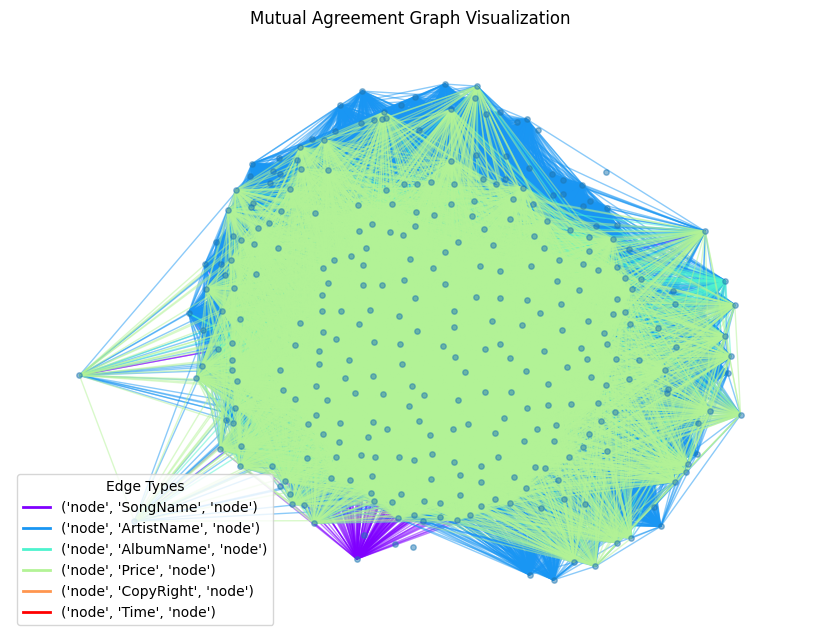

In [15]:
visualize_hetero_graph(mutual_agreement_graph)

## Build R-GNN Over The Graph

In [ ]:
def init_embeddings(left, right, model):
    X = []
    for l, r in tqdm(zip(left, right)):
        l_emb = model.encode(l, convert_to_tensor=True)
        r_emb = model.encode(r, convert_to_tensor=True)
        init_emb = torch.cat((l_emb, r_emb), axis=0)
        X.append(init_emb)
    X = torch.stack(X)
    return X

class RGNN(torch.nn.Module):
    ''''
        relational graph neural network for entity matching node classification task on heterogeneous graphs.
    '''
    def __init__(self, init_dim, channels, num_classes, edge_types, conv_type='GCN', agg_type='mean'):
        super(RGNN, self).__init__()
        self.init_dim = init_dim
        self.edge_types = edge_types
        self.num_relations = len(self.edge_types)
        self.num_classes = num_classes
        self.channels = [init_dim] + channels

        # Initialize the convolutional layers
        self.conv_layers = torch.nn.ModuleList()
        for in_channels, out_channels in zip(self.channels[:-1], self.channels[1:]):
            if conv_type == 'GCN':
                conv_dict = {edge_type:GCNConv(in_channels, out_channels) for edge_type in self.edge_types}
            elif conv_type == 'SAGE':
                conv_dict = {edge_type:SAGEConv(in_channels, out_channels) for edge_type in self.edge_types}
            else:
                raise ValueError(f"Unsupported convolution type {conv_type}. Use 'GCN' or 'SAGE'.")
            if agg_type == 'mean':
                self.conv_layers.append(HeteroConv(conv_dict, aggr='mean'))
            elif agg_type == 'sum':
                self.conv_layers.append(HeteroConv(conv_dict, aggr='sum'))
            elif agg_type == 'max':
                self.conv_layers.append(HeteroConv(conv_dict, aggr='max'))
            else:
                raise ValueError(f"Unsupported aggregation type {agg_type}. Use 'mean', 'sum', or 'max'.")
        self.linear = torch.nn.Linear(self.channels[-1], self.num_classes)
        self.activation = torch.nn.ReLU()


    def forward(self, x_dict, edge_index_dict, inference=False):
        for conv in self.conv_layers:
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {k: self.activation(v) for k, v in x_dict.items()}
        out_dict = {k: self.linear(v) for k, v in x_dict.items()}
        if inference:
            return out_dict, x_dict
        else:
            return out_dict

    

In [ ]:
# Training the model:
def train_model(model, data, labels, train_mask, val_mask, epochs=100, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    edge_index_dict = {edge_type: data[edge_type].edge_index for edge_type in data.edge_types}
    edge_type_dict = {edge_type: i for i, edge_type in enumerate(data.edge_types)}
    data.edge_index_dict = edge_index_dict
    data.edge_type_dict = edge_type_dict
    for epoch in tqdm(range(1, epochs+1)):
        model.train()
        optimizer.zero_grad()
        
        # Forward pass
        out = model(data.x_dict, data.edge_index_dict)
        out = out['node']
        # Compute loss
        loss = criterion(out[train_mask], labels[train_mask])
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        if (epoch) % 10 == 0:
            _, acc, f1 = evaluate_model(model, data, val_mask, labels)
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.4f}, Validation Accuracy: {acc:.4f}, Validation F1: {f1:.4f}')
    
    return model

def evaluate_model(model, data, eval_mask, labels):
    model.eval()
    with torch.no_grad():
        out = model(data.x_dict, data.edge_index_dict)
        out = out['node']
        _, predicted = torch.max(out, 1)
        labels = labels.cpu()
        predicted = predicted.cpu()
        eval_mask = eval_mask.cpu()
        accuracy = accuracy_score(labels[eval_mask], predicted[eval_mask])
        f1 = f1_score(labels[eval_mask], predicted[eval_mask])
    return predicted, accuracy, f1

def analyze_vspace(model, data, labels, sample_frac=0.1):
    model.eval()
    with torch.no_grad():
        out_dict, x_dict = model(data.x_dict, data.edge_index_dict, inference=True)
        out = out_dict['node']
        x = x_dict['node']
        # Sample a fraction of the nodes
        num_nodes = out.shape[0]
        sample_size = int(num_nodes * sample_frac)
        sampled_indices = np.random.choice(num_nodes, sample_size, replace=False)
        sampled_out = out[sampled_indices]
        sampled_x = x[sampled_indices]
        sampled_labels = labels[sampled_indices]
        
        # Compute pairwise distances
        pairwise_distances = []
        for i in range(sample_size):
            for j in range(sample_size):
                dist = torch.norm(sampled_x[i] - sampled_x[j])
                pairwise_distances.append(dist)
        
        # Compute mean and std of distances
        
        
    return sampled_out, sampled_x, sampled_labels, pairwise_distances

def plot_dist_histogram(dists):
    plt.figure(figsize=(10, 6))
    plt.hist(dists, bins=50, alpha=0.7, color='green')
    plt.title('Pairwise Distance Histogram')
    plt.xlabel('Distances')
    plt.ylabel('Frequency')
    plt.grid()
    plt.show()

def plot_vspace_reduced(x, labels):
    tsne =  TSNE(n_components=2, random_state=42)
    x_reduced = tsne.fit_transform(x)
    plt.figure(figsize=(10, 6))
    scatter_plot = plt.scatter(x_reduced[:, 0], x_reduced[:, 1], c=labels, cmap='tab10', alpha=0.5)
    plt.legend(*scatter_plot.legend_elements(), title="Classes")
    plt.title('Node Embeddings in t-SNE Space')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.grid()
    plt.show()

In [ ]:
X = init_embeddings(left, right, model)
X = X.to(device)

321it [00:03, 103.97it/s]


In [57]:
print(X.shape)

torch.Size([321, 768])


In [85]:
rgnn_model = RGNN(init_dim=384*2, channels=[256, 64], edge_types=mutual_agreement_graph.edge_types, num_classes=2)
rgnn_model = rgnn_model.to(device)

labels_tensor = torch.tensor(noisy_labels, dtype=torch.long).to(device)
true_labels_tensor = torch.tensor(labels, dtype=torch.long).to(device)
mutual_agreement_graph['node'].x = X
mutual_agreement_graph['node'].y = labels_tensor
mutual_agreement_graph = mutual_agreement_graph.to(device)


In [86]:
train_model(rgnn_model, mutual_agreement_graph, labels_tensor, epochs=50, lr=1e-2)

 46%|████▌     | 23/50 [00:00<00:00, 110.52it/s]

Epoch [9/50], Loss: 0.5320
Epoch [19/50], Loss: 0.3776
Epoch [29/50], Loss: 0.2947


100%|██████████| 50/50 [00:00<00:00, 116.73it/s]

Epoch [39/50], Loss: 0.2229
Epoch [49/50], Loss: 0.2141


RGNN(
  (conv_layers): ModuleList(
    (0-1): 2 x HeteroConv(num_relations=6)
  )
  (linear): Linear(in_features=64, out_features=2, bias=True)
  (activation): ReLU()
)

In [87]:
evaluated_labels, accuracy, f1 = evaluate_model(rgnn_model, mutual_agreement_graph, true_labels_tensor)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")   


Accuracy: 0.9657
F1 Score: 0.9663
